# 04. mood_tag 방식 vs description 방식 비교

같은 이미지에 대해 두 가지 추천 방식의 결과를 나란히 비교합니다.

| | 방식 A (mood_tag) | 방식 B (description) |
|---|---|---|
| VLM 출력 | 영어 키워드 | 영어 키워드 (동일) |
| 비교 대상 | cocktail mood_tag 임베딩 | cocktail description 임베딩 |
| 임베딩 파일 | `cocktail_embeddings.npy` | `cocktail_desc_embeddings.npy` |
| 문제점 | 14개 조합 → 최대 32개 동점 | 영어↔한국어 크로스링구얼 |

**사용법**: 마지막 셀에서 `IMAGE_NO` 숫자만 바꾸고 전체 실행

In [2]:
import pandas as pd
import numpy as np
import requests
import base64
import os
from IPython.display import Image, display

In [3]:
CSV_PATH       = "/home/piai/b2/PBA_AI_Project/modeling/data/cocktails_final.csv"
SAVE_DIR       = "/home/piai/b2/PBA_AI_Project/modeling/image/final"
IMAGE_DIR      = "/home/piai/다운로드/mood_tag/data"

TAG_EMBED_PATH = os.path.join(SAVE_DIR, "cocktail_embeddings.npy")
TAG_IDS_PATH   = os.path.join(SAVE_DIR, "cocktail_ids.npy")
DESC_EMBED_PATH= os.path.join(SAVE_DIR, "cocktail_desc_embeddings.npy")
DESC_IDS_PATH  = os.path.join(SAVE_DIR, "cocktail_desc_ids.npy")

VLM_MODEL   = "llava:7b"
EMBED_MODEL = "nomic-embed-text"
OLLAMA_BASE = "http://localhost:11434"

df = pd.read_csv(CSV_PATH)

tag_embeddings  = np.load(TAG_EMBED_PATH)
tag_ids         = np.load(TAG_IDS_PATH)
desc_embeddings = np.load(DESC_EMBED_PATH)
desc_ids        = np.load(DESC_IDS_PATH)

print(f"칵테일 수: {len(df)}")
print(f"mood_tag 임베딩: {tag_embeddings.shape}")
print(f"description 임베딩: {desc_embeddings.shape}")

칵테일 수: 101
mood_tag 임베딩: (101, 768)
description 임베딩: (101, 768)


In [4]:
def get_embedding(text):
    r = requests.post(f"{OLLAMA_BASE}/api/embeddings",
                      json={"model": EMBED_MODEL, "prompt": text})
    r.raise_for_status()
    return np.array(r.json()["embedding"])


def analyze_image(image_path):
    with open(image_path, "rb") as f:
        image_b64 = base64.b64encode(f.read()).decode("utf-8")
    prompt = (
        "Describe the mood and atmosphere of this space. "
        "Focus on lighting, color tone, emotional feeling, and social setting. "
        "Give 5 to 10 English keywords or short phrases separated by commas."
    )
    r = requests.post(f"{OLLAMA_BASE}/api/generate",
                      json={"model": VLM_MODEL, "prompt": prompt,
                            "images": [image_b64], "stream": False})
    r.raise_for_status()
    return r.json()["response"].strip()


def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def top_k_results(query_emb, embeddings, ids, top_k=5):
    sims = np.array([cosine_sim(query_emb, e) for e in embeddings])
    top_indices = np.argsort(sims)[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices, 1):
        cid = ids[idx]
        row = df[df["cocktail_id"] == cid].iloc[0]
        results.append({
            "순위": rank,
            "이름": row["name_kr"],
            "mood_tag": row["mood_tag"],
            "유사도": round(sims[idx], 4),
            "_cid": cid,
        })
    return results


def compare(image_no, top_k=5):
    image_path = os.path.join(IMAGE_DIR, f"image_{image_no:03d}.jpg")
    print(f"[이미지] {os.path.basename(image_path)}")
    display(Image(filename=image_path, width=420))

    print("VLM 분석 중...")
    vlm_text = analyze_image(image_path)
    print(f"\n[VLM 출력]\n{vlm_text}\n")

    query_emb = get_embedding(vlm_text)

    tag_results  = top_k_results(query_emb, tag_embeddings,  tag_ids,  top_k)
    desc_results = top_k_results(query_emb, desc_embeddings, desc_ids, top_k)

    tag_cids  = {r["_cid"] for r in tag_results}
    desc_cids = {r["_cid"] for r in desc_results}

    rows = []
    for i in range(top_k):
        t = tag_results[i]
        d = desc_results[i]
        rows.append({
            "순위": i + 1,
            "[A] mood_tag 방식": t["이름"],
            "A 유사도": t["유사도"],
            "[B] description 방식": d["이름"],
            "B 유사도": d["유사도"],
            "일치": "✅" if t["_cid"] == d["_cid"] else "❌",
        })

    result_df = pd.DataFrame(rows)
    display(result_df)

    match_count   = sum(1 for r in rows if r["일치"] == "✅")
    overlap_count = len(tag_cids & desc_cids)
    print(f"순위별 일치: {match_count}/{top_k}  |  Top-{top_k} 겹치는 칵테일 수: {overlap_count}/{top_k}")

    print("\n[A] mood_tag 방식 상세")
    display(pd.DataFrame([{k: v for k, v in r.items() if k != "_cid"} for r in tag_results]))
    print("[B] description 방식 상세")
    display(pd.DataFrame([{k: v for k, v in r.items() if k != "_cid"} for r in desc_results]))

[이미지] image_001.jpg


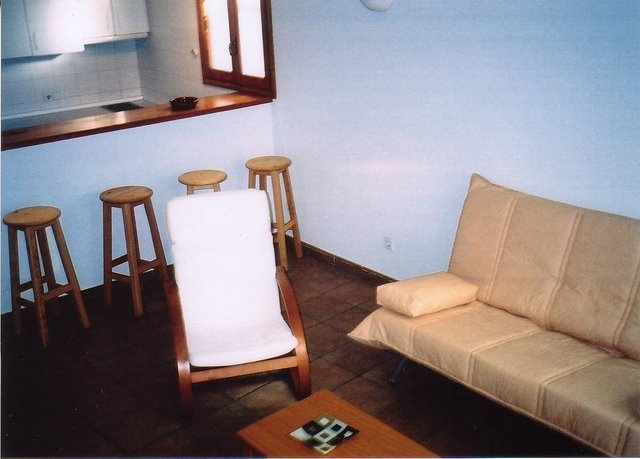

VLM 분석 중...

[VLM 출력]
Mood: Empty, sterile

Atmosphere: Bare, minimalistic, functional

Lighting: Dim and artificial with no natural light

Color tone: Cool tones with a blue wall as the backdrop

Emotional feeling: Loneliness, isolation, uninhabited

Social setting: Vacant living space, no signs of personalization or warmth

Keywords/phrases: Clean, bare, minimalistic, empty, unoccupied, functional, dimly lit, cool tones, no natural light, lonely, isolated, vacant living space, uninhabited, sterile



,순위,[A] mood_tag 방식,A 유사도,[B] description 방식,B 유사도,일치
0,1,행키팽키,0.559,버진 메리,0.5574,❌
1,2,네그로니,0.559,콥스 리바이버 No.2,0.5534,❌
2,3,페이퍼 플레인,0.559,셜리 템플,0.5530,❌
3,4,불바디에,0.559,그래스호퍼,0.5512,❌
4,5,네이키드 앤 페이머스,0.559,버진 피냐 콜라다,0.5507,❌


순위별 일치: 0/5  |  Top-5 겹치는 칵테일 수: 0/5

[A] mood_tag 방식 상세


,순위,이름,mood_tag,유사도
0,1,행키팽키,relaxing|dark|modern,0.559
1,2,네그로니,relaxing|dark|modern,0.559
2,3,페이퍼 플레인,relaxing|dark|modern,0.559
3,4,불바디에,relaxing|dark|modern,0.559
4,5,네이키드 앤 페이머스,relaxing|dark|modern,0.559


[B] description 방식 상세


,순위,이름,mood_tag,유사도
0,1,버진 메리,savory|classic|brunch,0.5574
1,2,콥스 리바이버 No.2,social|cool|casual,0.5534
2,3,셜리 템플,bright|playful|casual,0.5530
3,4,그래스호퍼,cozy|warm|private,0.5512
4,5,버진 피냐 콜라다,cozy|bright|casual,0.5507


In [5]:
# ── 여기서 이미지 번호만 바꾸면 됩니다 ──
IMAGE_NO = 1

compare(IMAGE_NO)

전체 이미지 수: 294


100%|██████████| 294/294 [04:39<00:00,  1.05it/s]



완료: 294장 / 실패: 0장
평균 겹침: 0.18 / 5


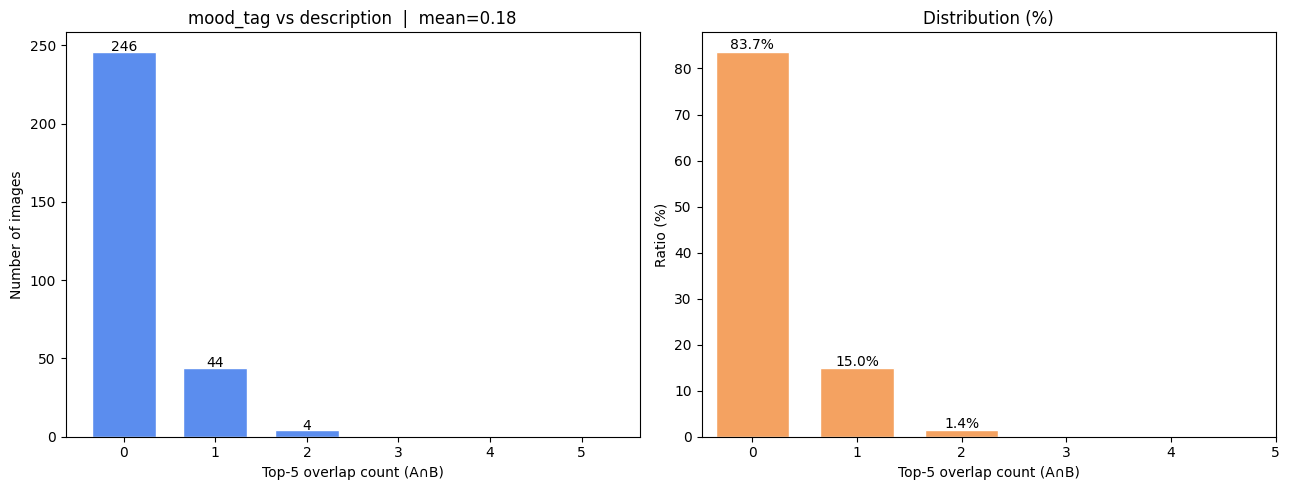

그래프 저장: overlap_distribution.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm

matplotlib.rcParams["font.family"] = "DejaVu Sans"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.startswith("image_") and f.endswith(".jpg")
])
print(f"전체 이미지 수: {len(image_files)}")

overlap_counts = []   # 이미지별 top-5 겹치는 수
failed = []

for fname in tqdm(image_files):
    image_path = os.path.join(IMAGE_DIR, fname)
    try:
        vlm_text  = analyze_image(image_path)
        query_emb = get_embedding(vlm_text)

        tag_res  = top_k_results(query_emb, tag_embeddings,  tag_ids,  top_k=5)
        desc_res = top_k_results(query_emb, desc_embeddings, desc_ids, top_k=5)

        tag_cids  = {r["_cid"] for r in tag_res}
        desc_cids = {r["_cid"] for r in desc_res}
        overlap_counts.append(len(tag_cids & desc_cids))
    except Exception as e:
        print(f"[오류] {fname}: {e}")
        failed.append(fname)

print(f"\n완료: {len(overlap_counts)}장 / 실패: {len(failed)}장")
print(f"평균 겹침: {np.mean(overlap_counts):.2f} / 5")

# 분포 그래프
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts_arr = np.array(overlap_counts)
bins = range(0, 7)
axes[0].hist(counts_arr, bins=bins, align="left", rwidth=0.7, color="#5b8dee", edgecolor="white")
axes[0].set_xticks(range(6))
axes[0].set_xlabel("Top-5 overlap count (A∩B)")
axes[0].set_ylabel("Number of images")
axes[0].set_title(f"mood_tag vs description  |  mean={np.mean(counts_arr):.2f}")
for x in range(6):
    n = int((counts_arr == x).sum())
    if n > 0:
        axes[0].text(x, n + 0.3, str(n), ha="center", fontsize=10)

# 누적 비율
unique, cnts = np.unique(counts_arr, return_counts=True)
pct = cnts / len(counts_arr) * 100
axes[1].bar(unique, pct, color="#f4a261", edgecolor="white", width=0.7)
axes[1].set_xticks(range(6))
axes[1].set_xlabel("Top-5 overlap count (A∩B)")
axes[1].set_ylabel("Ratio (%)")
axes[1].set_title("Distribution (%)")
for x, p in zip(unique, pct):
    axes[1].text(x, p + 0.5, f"{p:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "overlap_distribution.png"), dpi=150)
plt.show()
print("그래프 저장: overlap_distribution.png")


[이미지] image_167.jpg


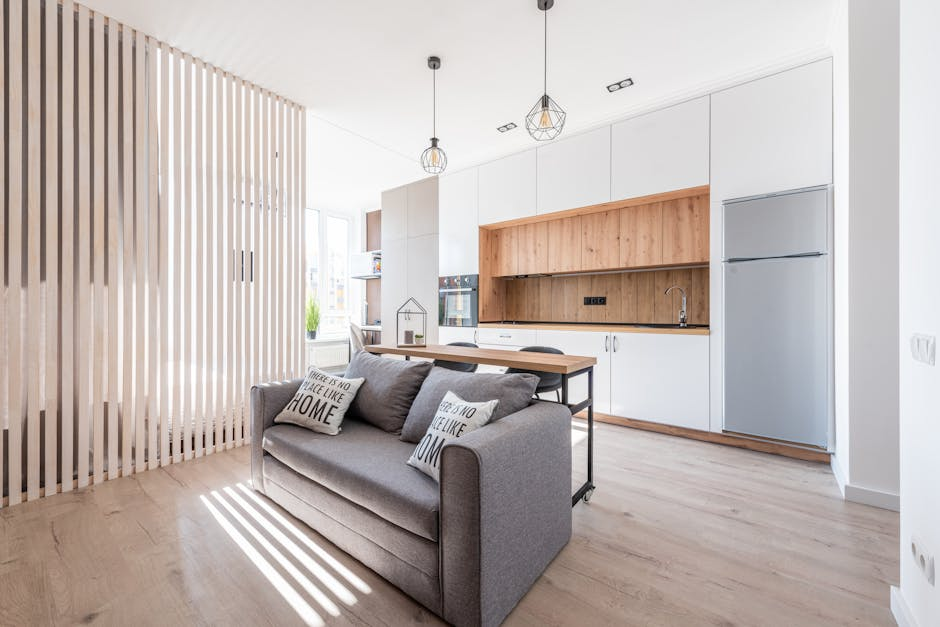

VLM 분석 중...

[VLM 출력]
Modern, Clean, Bright, Open, Spacious, Minimalist, Calm, Inviting, Rustic, Airy.



,순위,[A] mood_tag 방식,A 유사도,[B] description 방식,B 유사도,일치
0,1,그래스호퍼,0.4669,모히토,0.8956,❌
1,2,에스프레소 마티니,0.4669,메리 픽포드,0.8945,❌
2,3,피나 콜라다,0.4669,버진 메리,0.8940,❌
3,4,블랙 러시안,0.4669,벨리니,0.8939,❌
4,5,버진 모히토,0.4618,피스코 펀치,0.8939,❌


순위별 일치: 0/5  |  Top-5 겹치는 칵테일 수: 0/5

[A] mood_tag 방식 상세


,순위,이름,mood_tag,유사도
0,1,그래스호퍼,cozy|warm|private,0.4669
1,2,에스프레소 마티니,cozy|warm|private,0.4669
2,3,피나 콜라다,cozy|warm|private,0.4669
3,4,블랙 러시안,cozy|warm|private,0.4669
4,5,버진 모히토,social|bright|casual,0.4618


[B] description 방식 상세


,순위,이름,mood_tag,유사도
0,1,모히토,lively|bright|spacious,0.8956
1,2,메리 픽포드,social|warm|spacious,0.8945
2,3,버진 메리,savory|classic|brunch,0.8940
3,4,벨리니,social|bright|spacious,0.8939
4,5,피스코 펀치,social|warm|spacious,0.8939


In [8]:
# ── 여기서 이미지 번호만 바꾸면 됩니다 ──
IMAGE_NO = 167

compare(IMAGE_NO)